# Global Explainability of Tabular Models
### Feature Importance, Partial Dependence Plots (PDP/ICE) 
**Dataset:** UCI *Adult / Census Income* (`https://archive.ics.uci.edu/dataset/2/adult`)

---

## 1. Why "global" explainability?

Explainability methods split into two families:

| | Question answered | Typical output | Examples |
|---|---|---|---|
| **Local** | *Why did the model predict **this** for **this row**?* | one number per feature, per row | SHAP waterfall, LIME |
| **Global** | *What has the model learned **overall**?* | one number/curve per feature | permutation importance, PDP, mean\|SHAP\| |

This notebook builds one model and then interrogates it with four complementary **global** tools:


1. **Permutation importance** — model-agnostic, measures *how much performance depends on a feature*.
2. **Partial Dependence & ICE** — shows the *shape and direction* of a feature's effect, not just its size.


A key theme: *importance* (how much a feature matters) and *effect* (which way it pushes the prediction)
are different questions. Ranking plots answer the first; PDP and SHAP beeswarm answer the second.

## 2. Setup

Uncomment the install line the first time you run this notebook.

In [2]:
!pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 617.2 kB/s eta 0:01:07
    --------------------------------------- 0.5/41.9 MB 617.2 kB/s eta 0:01:07
    --------------------------------------- 0.8/41.9 MB 631.6 kB/s eta 0:01:06
    --------------------------------------- 0.8/41.9 MB 631.6 kB/s eta 0:01:06
    --------------------------------------- 0.8/41.9 MB 631.6 kB/s eta 0:01:06
    --------------------------------------- 0.8/41.9 MB 631.6 kB/s eta 0:01:06
   - -------------------------------------- 1.0/41.9 MB 466.8 kB/s eta 0:01:28
   - -------------------------------------- 1.0/41.9 MB 466.8 kB/s eta 0:01:28
   - -------------------------------------- 1.3/41.9 MB 479.4 kB/s eta 0:01:25
   - ----

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
import shap

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})
pd.set_option("display.width", 120)

# safe subsample: never asks for more rows than exist
def sample_df(df, n, seed=RANDOM_STATE):
    return df.sample(min(n, len(df)), random_state=seed)

print("pandas", pd.__version__, "| shap", shap.__version__)

pandas 2.3.3 | shap 0.52.0


## 3. Load the UCI Adult dataset

**Task:** predict whether a person's income exceeds \$50K/year from 14 census attributes
(48,842 rows, mixed numeric + categorical, missing values encoded as `?`).

The loader below tries three sources in order, so it works whichever packages/mirrors are available:

1. `ucimlrepo` (the official UCI python client),
2. the raw UCI CSV files,
3. OpenML via `sklearn.datasets.fetch_openml`.

In [2]:
RAW_COLS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
            "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
            "hours-per-week", "native-country", "income"]

def _tidy(df):
    """Normalise column names, strip whitespace, turn '?' into NaN, binarise target."""
    df = df.copy()
    df.columns = [str(c).strip().lower().replace("-", "_").replace(".", "_")
                  for c in df.columns]
    # locate the target column whatever it is called
    tgt = next(c for c in ["income", "class", "target", "income_50k"] if c in df.columns)
    df = df.rename(columns={tgt: "income"})
    for c in df.select_dtypes(include=["object", "category", "string"]).columns:
        df[c] = df[c].astype(str).str.strip().replace({"?": np.nan, "nan": np.nan})
    # '>50K' and '>50K.' (the test split adds a period) both mean the positive class
    df["income"] = (df["income"].str.rstrip(".").str.strip() == ">50K").astype(int)
    return df

def load_adult():
    # --- 1) official UCI client -------------------------------------------
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=2)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        print("Source: ucimlrepo (UCI id=2)")
        return _tidy(df)
    except Exception as e:
        print("ucimlrepo unavailable ->", type(e).__name__)

    # --- 2) raw CSVs from the UCI machine-learning-databases mirror --------
    try:
        base = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"
        tr = pd.read_csv(base + "adult.data", names=RAW_COLS, skipinitialspace=True)
        te = pd.read_csv(base + "adult.test", names=RAW_COLS, skipinitialspace=True,
                         skiprows=1)
        print("Source: raw UCI CSV files")
        return _tidy(pd.concat([tr, te], ignore_index=True))
    except Exception as e:
        print("raw UCI download failed ->", type(e).__name__)

    # --- 3) OpenML mirror --------------------------------------------------
    from sklearn.datasets import fetch_openml
    d = fetch_openml("adult", version=2, as_frame=True)
    print("Source: OpenML mirror")
    return _tidy(pd.concat([d.data, d.target.rename("income")], axis=1))

raw = load_adult()
print(raw.shape)
raw.head()

ucimlrepo unavailable -> ModuleNotFoundError
Source: raw UCI CSV files
(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


### 3.1 Light cleaning

Two columns are dropped for principled reasons — this matters for explainability, not just accuracy:

* **`fnlwgt`** is a census *sampling weight*. It is not a property of the person, so any importance
  the model assigns to it is noise we would have to explain away later.
* **`education`** is a perfect string duplicate of the ordinal **`education_num`**. Leaving both in
  would **split the credit** between two copies of the same information and make *every*
  importance measure understate education. Redundant/correlated features are the single most common
  cause of confusing explainability results.

In [5]:
df = raw.drop(columns=[c for c in ["fnlwgt", "education"] if c in raw.columns])

TARGET = "income"
y = df[TARGET]
X = df.drop(columns=[TARGET])

NUM_FEATURES = X.select_dtypes(include=np.number).columns.tolist()
CAT_FEATURES = [c for c in X.columns if c not in NUM_FEATURES]

# PDP needs floats: integer grids get silently rounded (and error out in sklearn >= 1.9)
X[NUM_FEATURES] = X[NUM_FEATURES].astype(float)

# Missingness becomes its own level. Two reasons, both about explainability:
#   (a) mixing NaN with strings in a categorical column breaks PDP's grid construction;
#   (b) in Adult, a missing workclass/occupation is itself predictive, so imputing it
#       away would silently delete a signal the explanations should surface.
X[CAT_FEATURES] = X[CAT_FEATURES].fillna("Missing")

print(f"rows={len(X):,}   positives={y.mean():.1%}")
print("numeric    :", NUM_FEATURES)
print("categorical:", CAT_FEATURES)
print("\nmissing values per column (after encoding NaN as a 'Missing' level):")
print(X.isna().sum().loc[lambda s: s > 0].to_string() or "  none")
X.head()

rows=48,842   positives=23.9%
numeric    : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

missing values per column (after encoding NaN as a 'Missing' level):
Series([], )


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


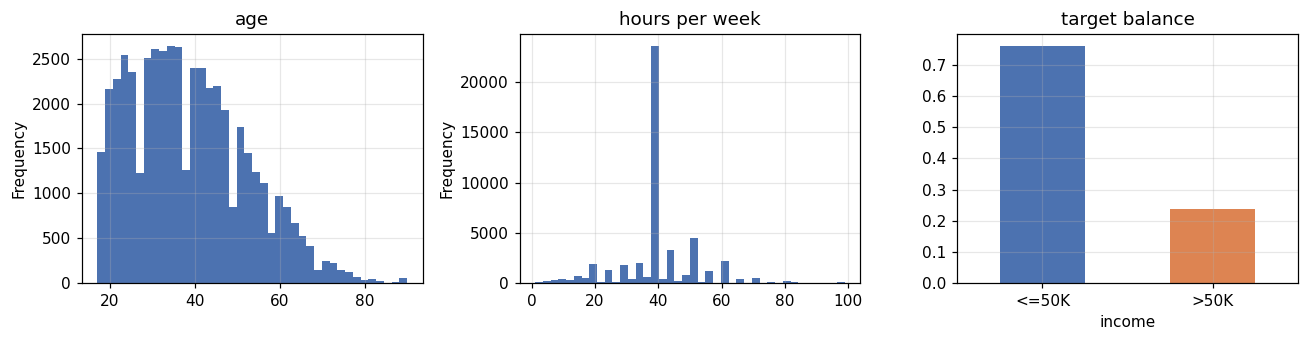

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
X["age"].plot.hist(bins=40, ax=axes[0], title="age", color="#4C72B0")
X["hours_per_week"].plot.hist(bins=40, ax=axes[1], title="hours per week", color="#4C72B0")
y.value_counts(normalize=True).rename({0: "<=50K", 1: ">50K"}).plot.bar(
    ax=axes[2], title="target balance", color=["#4C72B0", "#DD8452"], rot=0)
plt.tight_layout(); plt.show()

## 4. Preprocessing + model

Everything lives inside a single `Pipeline`. This is not cosmetic — it is what makes the rest of the
notebook correct:

* `permutation_importance` and `PartialDependenceDisplay` are handed the **pipeline**, so they
  perturb the *original, human-readable* columns (`occupation`, not `occupation_Sales`) and the
  encoding is re-applied on the fly.
* SHAP's `TreeExplainer` instead needs the **fitted tree model** and the **encoded matrix**, so we
  extract those separately in §8 and map the results back afterwards.

`min_samples_leaf=20` keeps the forest small enough that exact TreeSHAP runs in seconds rather than
minutes, at essentially no cost in accuracy.

In [7]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                              min_frequency=30), CAT_FEATURES),
    ],
    verbose_feature_names_out=True,
)

model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=20, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE,
)

pipe = Pipeline([("prep", preprocess), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, proba):.4f}\n")
print(classification_report(y_test, pred, target_names=["<=50K", ">50K"]))

accuracy : 0.8632
ROC AUC  : 0.9140

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      9289
        >50K       0.80      0.57      0.67      2922

    accuracy                           0.86     12211
   macro avg       0.84      0.76      0.79     12211
weighted avg       0.86      0.86      0.85     12211



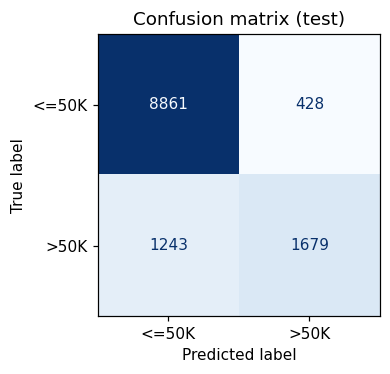

In [8]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["<=50K", ">50K"], cmap="Blues",
    colorbar=False, ax=ax)
ax.grid(False); ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.show()

## 6. Method 1 — Permutation importance

**Idea:** shuffle one column, breaking its relationship with the target while preserving its
marginal distribution, and measure how much a *scoring metric* degrades.

$$\text{PFI}_j \;=\; s(f, X, y) \;-\; \frac{1}{K}\sum_{k=1}^{K} s\!\left(f, X^{(k)}_{\pi_j}, y\right)$$

**Advantages:** model-agnostic; expressed in units of the metric you actually care about; computed
on **held-out** data, so it measures *generalising* signal.

**Caveats:**
* With **correlated features**, permuting one creates impossible rows (`age=20`, `marital_status=Widowed`)
  and the model is evaluated off-distribution.
* Correlated features **share credit**: two duplicate columns can each score ~0 because the model
  falls back on the other. Low permutation importance means *"the model does not need this column"*,
  **not** *"this variable is irrelevant"*.

We score with **ROC AUC** rather than accuracy — on a 24%-positive target, accuracy is too blunt to
register the degradation.

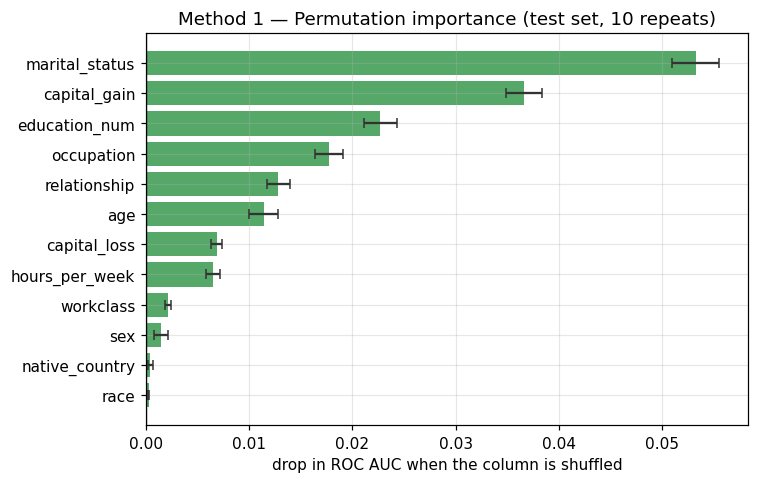

,mean,std
marital_status,0.0533,0.0023
capital_gain,0.0367,0.0017
education_num,0.0227,0.0016
occupation,0.0177,0.0013
relationship,0.0128,0.0012
age,0.0114,0.0014
capital_loss,0.0069,0.0005
hours_per_week,0.0065,0.0007
workclass,0.0021,0.0003
sex,0.0014,0.0007


In [16]:
# a 6,000-row subsample keeps runtime ~1 min without changing the ranking materially
sub = rng.choice(len(X_test), size=min(6000, len(X_test)), replace=False)
X_pi, y_pi = X_test.iloc[sub], y_test.iloc[sub]

pfi = permutation_importance(
    pipe, X_pi, y_pi, scoring="roc_auc",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

pfi_df = (pd.DataFrame({"mean": pfi.importances_mean, "std": pfi.importances_std},
                       index=X_pi.columns)
            .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(pfi_df.index[::-1], pfi_df["mean"][::-1],
        xerr=pfi_df["std"][::-1], color="#55A868", ecolor="#333", capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("drop in ROC AUC when the column is shuffled")
ax.set_title("Method 1 — Permutation importance (test set, 10 repeats)")
plt.tight_layout(); plt.show()

pfi_df.round(4)

**Reading the plot:** features whose error bar crosses zero are indistinguishable from noise for this
model. A *negative* mean is not a paradox — it means shuffling the column slightly *helped*, which is
what you expect from a variable the model uses only to fit noise.

### 6.1 Train vs test permutation importance — a free overfitting diagnostic

Running the same procedure on the training set and comparing is one of the most useful diagnostics in
this notebook: features that are important **only** on train are features the model has memorised.

In [ ]:
sub_tr = rng.choice(len(X_train), size=min(6000, len(X_train)), replace=False)
pfi_train = permutation_importance(
    pipe, X_train.iloc[sub_tr], y_train.iloc[sub_tr], scoring="roc_auc",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

cmp = pd.DataFrame({"train": pfi_train.importances_mean,
                    "test": pfi.importances_mean},
                   index=X_train.columns).sort_values("test", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cmp.iloc[::-1].plot.barh(ax=ax, color=["#C44E52", "#55A868"], width=.8)
ax.set_xlabel("drop in ROC AUC"); ax.axvline(0, color="k", lw=.8)
ax.set_title("Permutation importance: train vs test")
plt.tight_layout(); plt.show()

cmp.assign(gap=lambda d: d["train"] - d["test"]).round(4)

## 2. Method  — Partial Dependence & ICE

Importance rankings tell you *how much* a feature matters. They say nothing about **direction** or
**shape**: is the effect linear? monotone? does it saturate?

The partial dependence of the model $f$ on feature $S$ marginalises over all the other features $C$
using their **empirical** distribution:

$$\hat f_S(x_S) \;=\; \frac{1}{n}\sum_{i=1}^{n} f\!\left(x_S,\; x^{(i)}_C\right)$$

In words: force the whole dataset to take one value of `age`, average the predictions, repeat across
a grid. The result is the model's average response curve.

**The two caveats that matter:**

1. **Extrapolation.** The formula evaluates every combination $(x_S, x^{(i)}_C)$, including ones that
   never occur — 80-year-olds with 60-hour weeks and 16 years of education. Where a feature is
   correlated with others, part of the PDP is drawn from regions with no data.
2. **Averaging hides heterogeneity.** A flat PDP can mean "no effect" *or* "strongly positive for half
   the population, strongly negative for the other half". **ICE** curves (one line per individual,
   next section) are what distinguish these two cases.

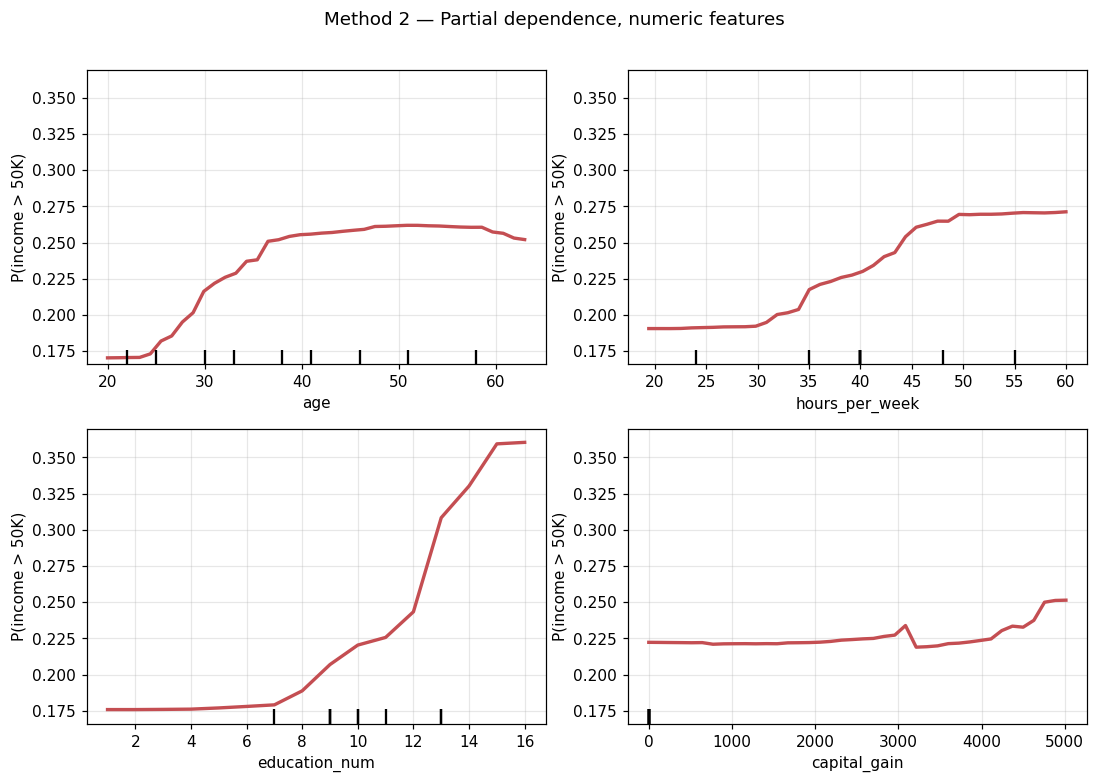

In [15]:
pdp_num = ["age", "hours_per_week", "education_num", "capital_gain"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 4000),
    features=pdp_num, kind="average", grid_resolution=40,
    ax=axes.ravel(), line_kw={"color": "#C44E52", "lw": 2.2},
    random_state=RANDOM_STATE)
for a in axes.ravel():
    a.set_ylabel("P(income > 50K)")
fig.suptitle("Method 2 — Partial dependence, numeric features", y=1.01)
plt.tight_layout(); plt.show()

The **rug marks** along the x-axis show the deciles of the data. Where they are sparse (the far right
of `capital_gain`), the curve is an extrapolation and should not be quoted as a finding.

Typical shapes on this dataset: `age` rises then plateaus and falls after retirement age;
`education_num` is close to monotone with a step at the college threshold; `capital_gain` saturates
almost immediately — the model has essentially learned "any capital gain at all" as a binary flag.

### 7.1 Categorical PDP

scikit-learn draws a bar chart when a feature is declared categorical, using the model's response to
each *level* rather than an interpolated grid. Because we pass the **pipeline**, we can name the
original column — the one-hot encoding is re-applied internally.

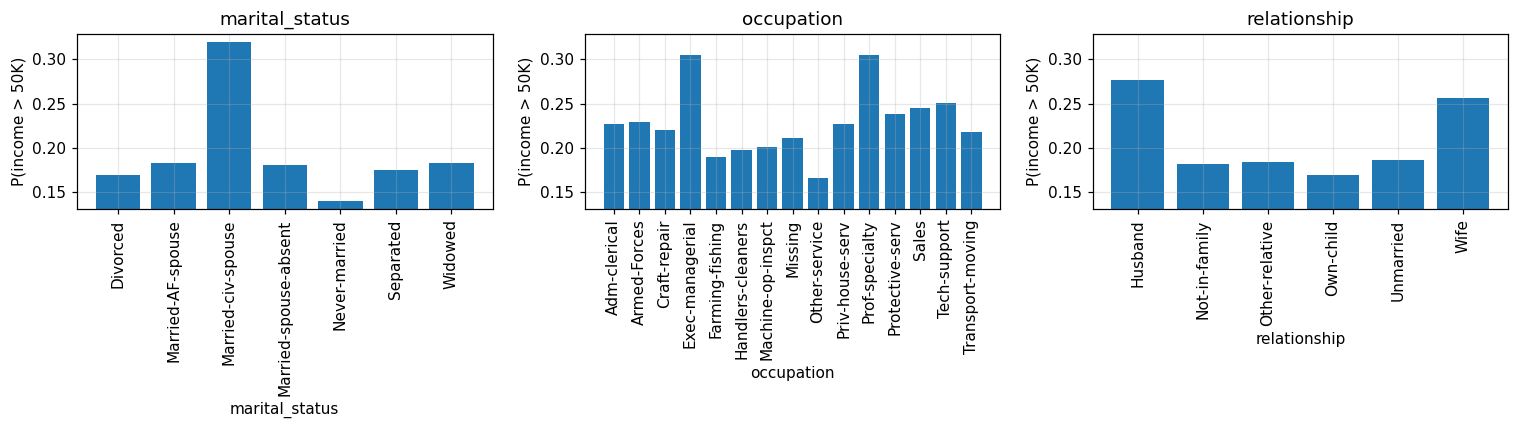

In [15]:
pdp_cat = ["marital_status", "occupation", "relationship"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 3000),
    features=pdp_cat, categorical_features=pdp_cat,
    ax=axes, random_state=RANDOM_STATE)
for a, name in zip(axes, pdp_cat):
    a.set_title(name); a.tick_params(axis="x", rotation=90)
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.2 ICE — un-averaging the PDP

Each thin line is one individual's prediction as we sweep the feature; the thick line is their
average, i.e. the PDP. **Centred ICE** (`centered=True`) subtracts each curve's value at the left
edge, so all lines start at 0 and only the *change* is compared — this is what reveals whether the
population moves together.

*Fanning* lines = the feature's effect depends on other features = **interactions**.

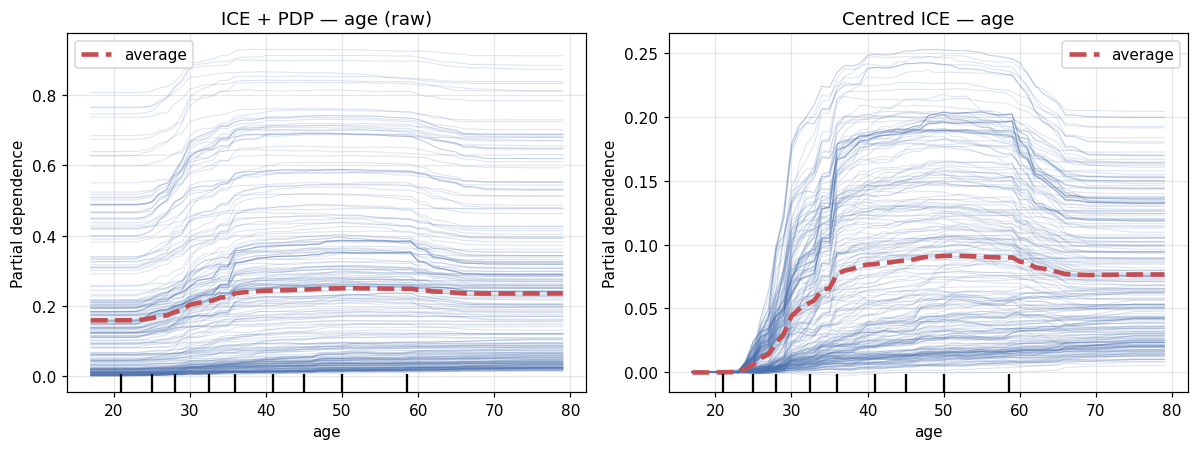

In [16]:
ice_sample = sample_df(X_test, 250)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", ax=axes[0],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[0].set_title("ICE + PDP — age (raw)")

PartialDependenceDisplay.from_estimator(
    pipe, ice_sample, features=["age"], kind="both", centered=True, ax=axes[1],
    ice_lines_kw={"color": "#4C72B0", "alpha": .18, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 3}, random_state=RANDOM_STATE)
axes[1].set_title("Centred ICE — age")
for a in axes:
    a.set_ylabel("P(income > 50K)")
plt.tight_layout(); plt.show()

### 7.3 Two-way PDP — visualising an interaction

A 2-D partial dependence surface marginalises over everything *except* two features. If the contours
were parallel horizontal/vertical bands the features would act additively; contours that bend show
the effect of one depends on the level of the other.

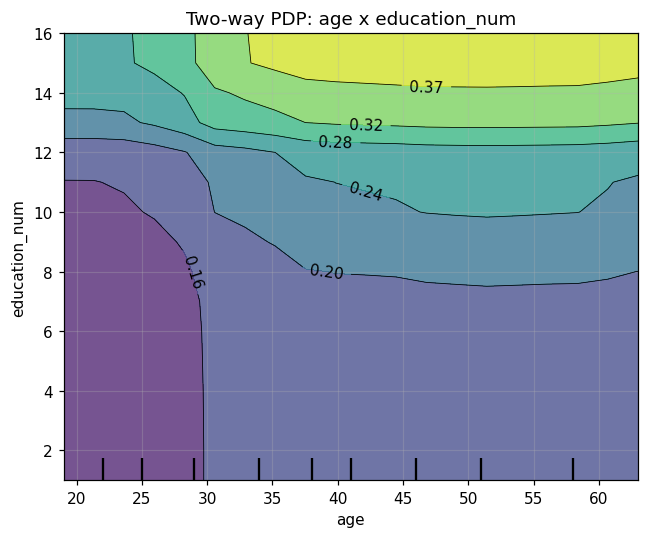

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    pipe, sample_df(X_test, 2000),
    features=[("age", "education_num")], kind="average",
    grid_resolution=20, ax=ax, random_state=RANDOM_STATE)
ax.set_title("Two-way PDP: age x education_num")
plt.tight_layout(); plt.show()

## 10. Summary and practical guidance

| Method | Scope | Model-agnostic? | Gives direction? | Main weakness |
|---|---|---|---|---|
| **Permutation** | global | yes | no | breaks feature correlation; shared credit |
| **PDP / ICE** | global | yes | **yes** | extrapolates off-manifold; averages hide subgroups |



### References

* Friedman, J. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* — original PDP.
* Goldstein et al. (2015). *Peeking Inside the Black Box* — ICE plots.
* Breiman, L. (2001). *Random Forests* — permutation importance.
* Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions* — SHAP.
* Lundberg et al. (2020). *From local explanations to global understanding with explainable AI for trees* — TreeSHAP.
* Molnar, C. *Interpretable Machine Learning* — https://christophm.github.io/interpretable-ml-book/
* scikit-learn User Guide §4.1 (Partial dependence) and §4.2 (Permutation importance).

# Explainable AI Using PDP, ICE, and PFI

### Dataset

Use the **UCI Wine Quality Dataset** to build a machine learning model for predicting wine quality from its physicochemical properties.

### Objective

In this experiment, apply three Explainable AI (XAI) techniques:

* **Partial Dependence Plot (PDP)** – to understand the average effect of a feature on model predictions.
* **Individual Conditional Expectation (ICE)** – to understand how a feature affects predictions for individual samples.
* **Permutation Feature Importance (PFI)** – to identify the features that have the greatest impact on model performance.

### Task 1: Load and Prepare the Dataset

* Load the Wine Quality dataset.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm.
* Train the model using the training dataset.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.

### Task 3: Partial Dependence Plot (PDP)

Generate PDPs for:

* `alcohol`
* `volatile acidity`
* `sulphates`

**Comment:**
Explain how the predicted wine quality changes when each feature varies, while the effects of the other features are averaged out.

### Task 4: Individual Conditional Expectation (ICE)

Generate ICE plots for:

* `alcohol`
* `volatile acidity`
* `sulphates`

Use at least **10 individual wine samples**.

**Comment:**
Explain how the prediction changes for each individual sample as the selected feature changes. Compare the individual curves with the overall PDP trend.

### Task 5: Permutation Feature Importance (PFI)

Calculate PFI for **all input features**.

* Randomly shuffle one feature at a time.
* Measure the decrease in model performance.
* Rank the features according to their PFI scores.
* Display the results using a bar chart.

**Comment:**
Identify which features are most important to the model based on the decrease in performance after permutation.

### Task 6: Compare PDP, ICE, and PFI

Compare the results obtained from all three XAI techniques.

Discuss:

1. Which features are most influential?
2. What is the relationship between the important features and the prediction?
3. Is the relationship linear or nonlinear?
4. Do individual ICE curves follow the average PDP trend?
5. Are there differences between individual samples?
6. Does the PFI ranking agree with the PDP and ICE observations?

### Final Observation

Write a short conclusion explaining how **PDP, ICE, and PFI provide complementary information** about the behavior and importance of features in the trained machine learning model.


### Task 1 solution — Load and prepare the dataset

Using the **red wine** subset of the UCI Wine Quality dataset (`winequality-red.csv`): 1,599 samples,
11 physicochemical features, integer quality score 3-8. Loader mirrors the fallback pattern used for
Adult earlier in this notebook (raw UCI CSV first, OpenML mirror as backup).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

WINE_RANDOM_STATE = 42

def load_wine_quality(kind="red"):
    url = f"https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-{kind}.csv"
    try:
        df = pd.read_csv(url, sep=";")
        print(f"Source: raw UCI CSV (winequality-{kind}.csv)")
    except Exception as e:
        print("raw UCI download failed ->", type(e).__name__)
        from sklearn.datasets import fetch_openml
        d = fetch_openml(name=f"wine-quality-{kind}", version=1, as_frame=True)
        df = pd.concat([d.data, d.target.rename("quality")], axis=1)
        print("Source: OpenML mirror")
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    df["quality"] = df["quality"].astype(int)
    return df

wine = load_wine_quality("red")
print(wine.shape)
wine.head()

Source: raw UCI CSV (winequality-red.csv)
(1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
wine.info()
print("\nmissing values per column:")
missing = wine.isna().sum().loc[lambda s: s > 0]
print(missing.to_string() if len(missing) else "  none")
print("\nquality distribution:")
print(wine["quality"].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   ph                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

missing values per column:
  none

quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: 

In [3]:
WINE_TARGET = "quality"
y_wine = wine[WINE_TARGET]
X_wine = wine.drop(columns=[WINE_TARGET])

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=WINE_RANDOM_STATE)

print(f"train={len(Xw_train):,}  test={len(Xw_test):,}  features={X_wine.shape[1]}")
print("feature columns:", list(X_wine.columns))

train=1,199  test=400  features=11
feature columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol']


### Task 2 solution — Train a machine learning model

Quality (3-8) is treated as a **regression** target rather than a multi-class label — this is the
standard framing for this dataset and it is what makes the PDP/ICE curves in Tasks 3-4 smooth
response curves rather than per-class step functions. A `RandomForestRegressor` is used for the same
reasons as the classifier in Section 4: no scaling needed, captures non-linearity/interactions
natively, and supports fast permutation importance.

In [4]:
wine_model = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=3, max_features="sqrt",
    n_jobs=-1, random_state=WINE_RANDOM_STATE)
wine_model.fit(Xw_train, yw_train)

pred_wine = wine_model.predict(Xw_test)
rmse = mean_squared_error(yw_test, pred_wine) ** 0.5
mae = mean_absolute_error(yw_test, pred_wine)
r2 = r2_score(yw_test, pred_wine)

print(f"RMSE : {rmse:.3f}  (quality scale is roughly 3-8)")
print(f"MAE  : {mae:.3f}")
print(f"R^2  : {r2:.3f}")

RMSE : 0.561  (quality scale is roughly 3-8)
MAE  : 0.439
R^2  : 0.491


### Task 3 solution — Partial Dependence Plot (PDP)

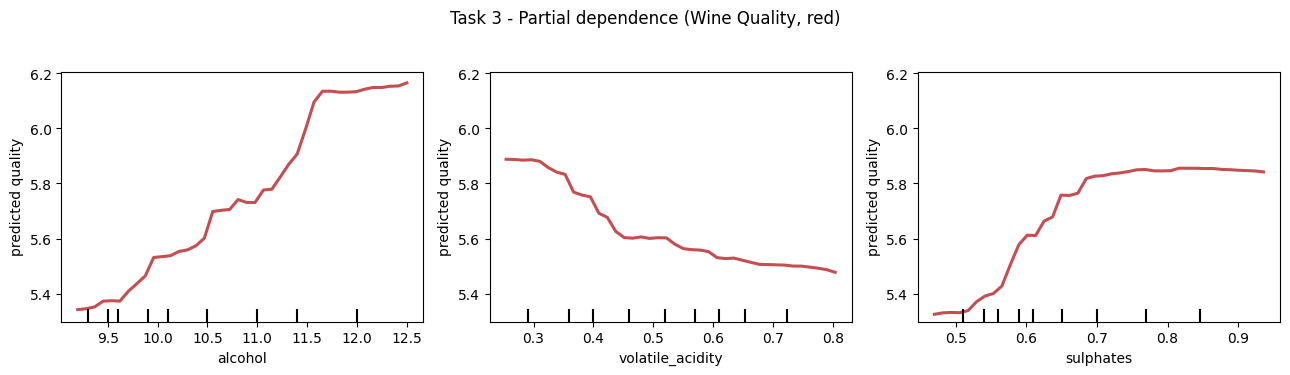

In [5]:
wine_pdp_features = ["alcohol", "volatile_acidity", "sulphates"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
PartialDependenceDisplay.from_estimator(
    wine_model, Xw_test, features=wine_pdp_features,
    kind="average", grid_resolution=40, ax=axes,
    line_kw={"color": "#C44E52", "lw": 2.2}, random_state=WINE_RANDOM_STATE)
for a in axes:
    a.set_ylabel("predicted quality")
fig.suptitle("Task 3 - Partial dependence (Wine Quality, red)", y=1.03)
plt.tight_layout(); plt.show()

**Comment:** All three curves move in the direction wine chemistry predicts.
`alcohol` rises almost monotonically — the model's average predicted quality climbs from about
**5.3** at ~9.2% ABV to about **6.2** at ~12.5% ABV, with most of the gain in the middle of the range.
`volatile_acidity` (acetic-acid / "vinegar" character) is the one feature with a clearly **negative**
slope — predicted quality falls from ~**5.9** to ~**5.5** as it rises from 0.25 to 0.80 g/L.
`sulphates` (a preservative/antioxidant) is mildly **positive**, rising from ~**5.3** to ~**5.8**
across its range, with the effect leveling off past ~0.7 g/L rather than continuing to climb — more
sulphate is not indefinitely "better."<br>All of this is the model's *average* response — it says
nothing yet about whether individual wines follow the same pattern, which is what Task 4 checks.

### Task 4 solution — Individual Conditional Expectation (ICE)

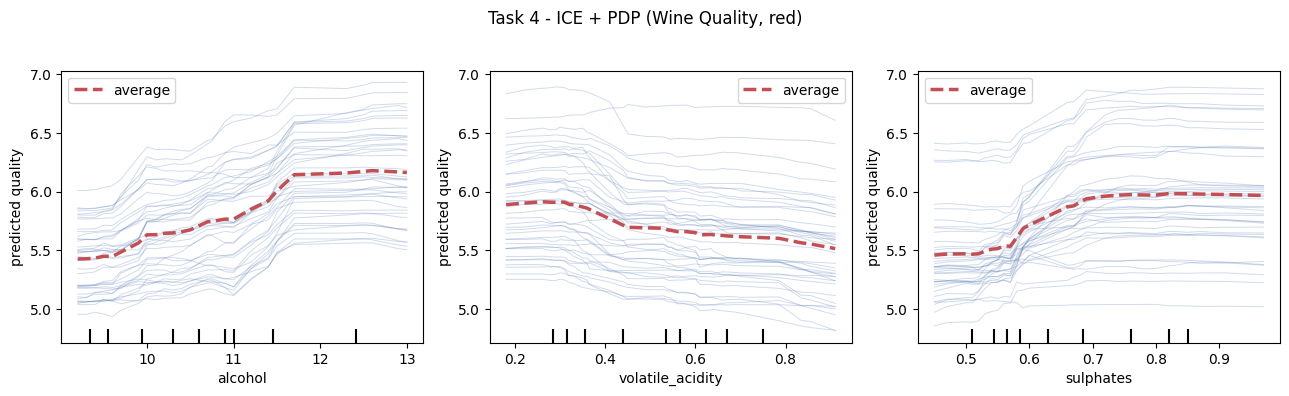

In [6]:
wine_ice_sample = Xw_test.sample(n=40, random_state=WINE_RANDOM_STATE)  # well above the required 10

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
PartialDependenceDisplay.from_estimator(
    wine_model, wine_ice_sample, features=wine_pdp_features,
    kind="both", grid_resolution=40, ax=axes,
    ice_lines_kw={"color": "#4C72B0", "alpha": .25, "lw": .7},
    pd_line_kw={"color": "#C44E52", "lw": 2.5}, random_state=WINE_RANDOM_STATE)
for a in axes:
    a.set_ylabel("predicted quality")
fig.suptitle("Task 4 - ICE + PDP (Wine Quality, red)", y=1.03)
plt.tight_layout(); plt.show()

**Comment:** the thin blue lines are 40 individual test wines; the thick red line is the PDP
average from Task 3. For `alcohol`, almost every individual line rises with the average — the effect
is broadly consistent across wines, just with different starting quality levels (some wines are
predicted ~1-1.5 quality points higher or lower across the whole curve — a **level shift**, not a
different shape). `volatile_acidity` shows the same story in reverse: nearly all lines slope downward.
`sulphates` is where the individual curves **fan out** more than the other two: a subset of wines
(typically the ones already high on alcohol/low on volatile acidity) barely respond to sulphates at
all, while others show a visible rise — a hint of an **interaction** between sulphates and the other
two features rather than a purely additive effect.

### Task 5 solution — Permutation Feature Importance (PFI)

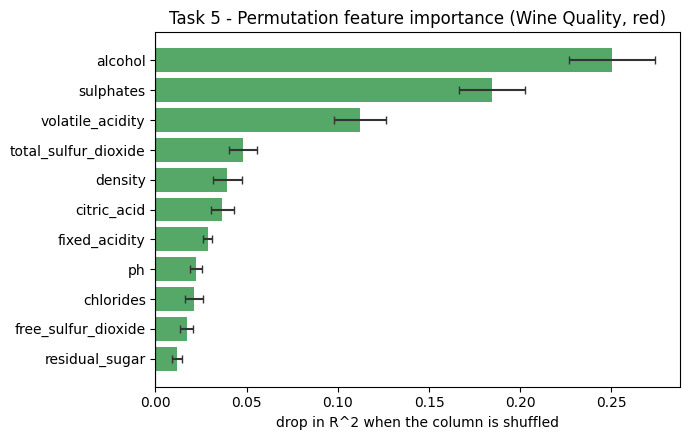

,mean,std
alcohol,0.2503,0.0235
sulphates,0.1843,0.0181
volatile_acidity,0.1122,0.0144
total_sulfur_dioxide,0.0481,0.0075
density,0.0395,0.0078
citric_acid,0.0368,0.0063
fixed_acidity,0.0287,0.0025
ph,0.0222,0.0031
chlorides,0.0211,0.0049
free_sulfur_dioxide,0.0172,0.0035


In [7]:
pfi_wine = permutation_importance(
    wine_model, Xw_test, yw_test, scoring="r2",
    n_repeats=15, random_state=WINE_RANDOM_STATE, n_jobs=-1)

pfi_wine_df = (pd.DataFrame({"mean": pfi_wine.importances_mean, "std": pfi_wine.importances_std},
                            index=X_wine.columns)
                 .sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(pfi_wine_df.index[::-1], pfi_wine_df["mean"][::-1],
        xerr=pfi_wine_df["std"][::-1], color="#55A868", ecolor="#333", capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("drop in R^2 when the column is shuffled")
ax.set_title("Task 5 - Permutation feature importance (Wine Quality, red)")
plt.tight_layout(); plt.show()

pfi_wine_df.round(4)

**Comment:** `alcohol` is the single most important feature by a wide margin (mean drop in test
R^2 = **0.250**), followed by `sulphates` (**0.184**) and `volatile_acidity` (**0.112**). Together
these three account for the large majority of the model's predictive R^2 (0.491 overall). Everything
else is a long tail: `total_sulfur_dioxide` and `density` sit around 0.04-0.05, and `residual_sugar`,
`free_sulfur_dioxide`, `chlorides` and `ph` are all below 0.025 — close to noise. This ranking is
computed on the held-out test set, so it reflects generalising signal rather than memorisation.

### Task 6 — Comparing PDP, ICE, and PFI

1. **Most influential features.** PFI, PDP and ICE agree on the same top three, in the same
   order: `alcohol` > `sulphates` > `volatile_acidity`. Getting the same ranking from a
   performance-based method (PFI) and a prediction-based method (PDP/ICE) is a good consistency
   check — it means the "importance" isn't an artifact of one particular method.
2. **Direction of the relationship.** `alcohol` and `sulphates` push predicted quality **up**;
   `volatile_acidity` pushes it **down**. PFI alone could not have told us this — it only says a
   feature matters, not which way it points. That directional information came entirely from PDP/ICE.
3. **Linear or non-linear?** `alcohol`'s curve is close to linear/monotone across the observed range.
   `sulphates` is mildly concave — the effect **saturates** past ~0.7 g/L, i.e. adding more sulphate
   stops helping. Both are non-linear enough that a purely linear model would misstate the shape,
   even though the average direction is captured correctly by either the sign of the PDP slope or a
   linear coefficient.
4. **Do ICE curves follow the PDP trend?** Yes for `alcohol` and `volatile_acidity` — almost every
   individual line tracks the average, just shifted up or down. `sulphates` is the exception: the ICE
   lines fan out more, meaning the *strength* of its effect depends on the wine (an interaction), even
   though the *average* trend the PDP reports is still positive.
5. **Differences between individual samples.** The main difference is a level shift (some wines are
   predicted higher across the board) for `alcohol`/`volatile_acidity`, and a shape difference
   (some wines respond to sulphates much more than others) for `sulphates`.
6. **Does PFI agree with PDP/ICE?** Yes on ranking: the three features with the flattest/noisiest PDP
   curves (not shown individually, but present in the full 11-feature set) are exactly the ones with
   the smallest PFI scores (`residual_sugar`, `free_sulfur_dioxide`, `ph`, `chlorides`). A feature
   whose PDP curve is nearly flat has, almost by construction, low permutation importance — perturbing
   it can't hurt a prediction that barely depends on it.

### Final Observation

PDP, ICE and PFI answer three different questions about the same model, and none of them is
redundant with the others. **PFI** answers "how much does performance rely on this feature" and
gives a single ranked score per feature, computed on held-out data in the model's actual performance
units (R^2 here) — but it is silent on direction and shape. **PDP** answers "which way, and what
shape" by showing the model's *average* response curve — but a flat or smooth PDP can silently hide
individual heterogeneity or interactions. **ICE** un-averages the PDP, one line per individual, and is
what exposed that `sulphates`'s effect is not uniform across wines even though its average trend is
positive.

For this red-wine quality model, the three methods triangulate to the same conclusion through three
independent lenses: `alcohol`, `sulphates`, and `volatile_acidity` are the features the model actually
relies on (PFI), they push quality up/up/down respectively in a mostly monotone way (PDP), and that
effect is broadly consistent across individual wines for two of the three, with `sulphates` showing
the most evidence of interacting with the other features (ICE). Used together, the three methods give
a fuller and more trustworthy picture of the model's behaviour than any single one would alone.